In [544]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [545]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.05 ):
            control_[:,:,i_time] = maxI_
    return control_

def diff_control(diff_):
    d_int = 0.
    for n in range(diff_.shape[0]):
        for v in range(diff_.shape[1]):
            for t in range(diff_.shape[2]):
                d_int += np.abs(diff_[n,v,t]) * aln.params.dt
    return d_int
        

In [577]:
rates_exc_init = np.array( [[15. ]] )
rates_inh_init = np.array( [[15. ]] )
mufe_init = np.array( [[1. ]] )  # mV/ms
mufi_init = np.array( [[1. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

In [573]:
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
            
def setparams():
    
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    
    aln.params.sigmae_ext = 0.1
    aln.params.sigmai_ext = 0.1
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.

    
    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.


In [574]:
dur_pre = 0.
dur_post = 0.

max_it = 1
tol = 1e-30

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])


In [575]:
def plot_fig(i, control):
    lines = 2
    height = lines * 3
    fig, axes = plt.subplots(lines,2, figsize=(18, height))
    axes[0,i].plot(aln.t, control[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    
    """
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    axes[4,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    axes[5,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    axes[5,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    axes[6,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    axes[6,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")
    """

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()
    
def plot_dif(diff_):
    fig, axes = plt.subplots(1,2, figsize=(18, 3))
    axes[0].plot(aln.t, diff_[0,:], label="difference in exc rate")
    axes[1].plot(aln.t, diff_[1,:], label="difference in inh rate")

    for j in range(2):
        axes[j].legend()

    plt.tight_layout()
    
def plot_phi(phi):
    lines = 9
    time = np.arange(0, dur+aln.params.dt, aln.params.dt)
    
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    
    axes[0,0].plot(time, phi[0,0,:], label="phi0 - adjoint exc rate")
    axes[0,1].plot(time, phi[0,1,:], label="phi1 - adjoint inh rate")
    
    axes[1,0].plot(time, phi[0,2,:], label="phi2 - adjoint mufe")
    axes[1,1].plot(time, phi[0,3,:], label="phi3 - adjoint mufi")
    
    axes[2,0].plot(time, phi[0,6,:], label="phi6 - adjoint seim")
    axes[2,1].plot(time, phi[0,8,:], label="phi8 - adjoint siim")
    
    axes[3,0].plot(time, phi[0,4,:], label="phi4 - adjoint IA")
    axes[3,1].plot(time, phi[0,17,:], label="phi17 - adjoint V")
    
    axes[4,0].plot(time, phi[0,5,:], label="phi6 - adjoint seem")
    axes[4,1].plot(time, phi[0,7,:], label="phi8 - adjoint siem")
    
    axes[5,0].plot(time, phi[0,9,:], label="phi9 - adjoint seev")
    axes[5,0].plot(time, phi[0,10,:], label="phi10 - adjoint seiv")
    axes[5,1].plot(time, phi[0,11,:], label="phi11 - adjoint siev")
    axes[5,1].plot(time, phi[0,12,:], label="phi12 - adjoint siiv")
    
    axes[6,0].plot(time, phi[0,13,:], label="phi13 - adjoint mue ou")
    axes[6,1].plot(time, phi[0,14,:], label="phi14 - adjoint mui ou")
    
    axes[7,0].plot(time, phi[0,15,:], label="phi15 - adjoint sigma e")
    axes[7,1].plot(time, phi[0,16,:], label="phi16 - adjoint sigma i")
    
    axes[8,0].plot(time, phi[0,18,:], label="phi18 - adjoint tau e")
    axes[8,1].plot(time, phi[0,19,:], label="phi19 - adjoint tau i")

    for k in range(lines):
        for j in range(2):
            axes[k,j].legend()

    plt.tight_layout()

max delay =  0


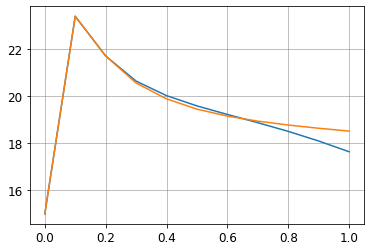

In [653]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

[15.     23.3977 21.7089 20.6249 19.9996 19.6852 19.26   18.8171 18.5291
 18.2029 17.831 ]
[15.     23.3977 24.7547 23.9558 15.1861 14.1995 16.1014 14.8408 14.2613
 14.3586 15.0471]


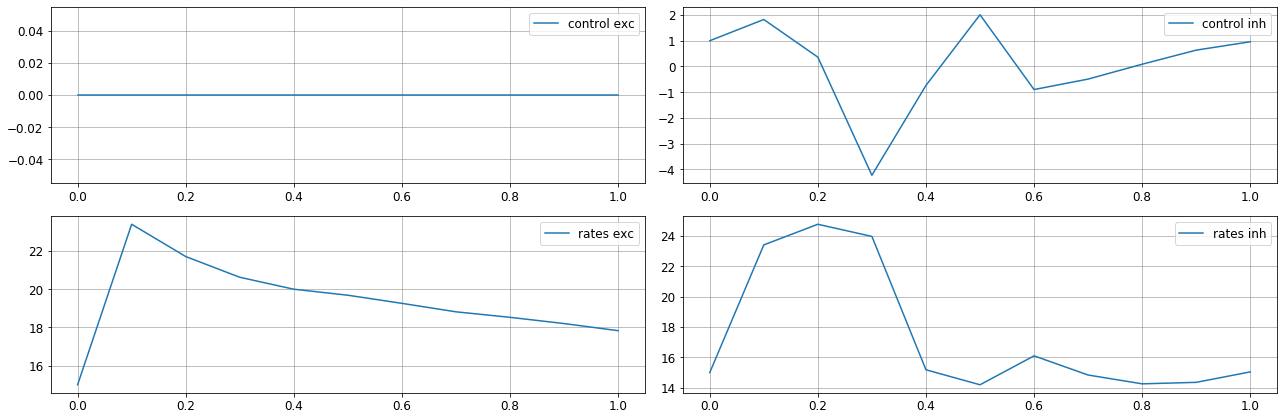

In [654]:
#setparams()

dur = 1.
aln.params.duration = dur
aln.params.di = 0.0
aln.params.de = 0.0

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)
setparams()

#control1 = aln.getZeroControl()
control1[0,1,3] -= 4.
control1[0,1,1] += 1.
control1[0,1,5] += 3.
#control1[0,1,5] -= 2.
control1[0,1,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0, control1)
plt.savefig("inh_control_no_delay.pdf")
rates1 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[15.     23.3977 21.7222 20.6471 20.0467 19.8013 19.5864 19.4845 19.137
 18.7005 18.3544]
[15.     23.3977 23.3977 22.0993 14.5515 14.4823 17.5711 17.5312 17.4388
 17.376  17.3748]


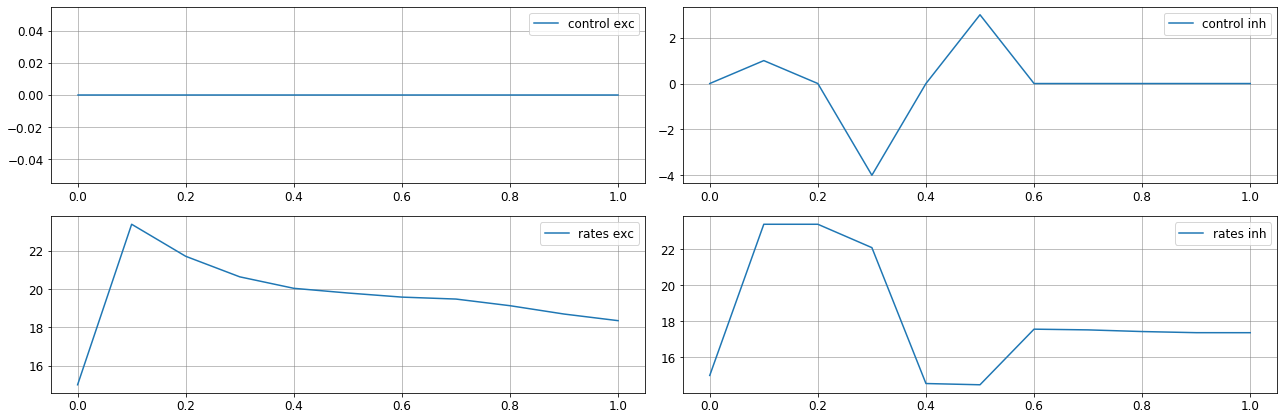

In [580]:
aln.params.di = 0.2
#control1[:,0,:] = 0.
set_init(initvars)
aln.run(control=control1)

rates2 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])
plot_fig(0, control1)
plt.savefig("inh_control_delay.pdf")
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

[ 0.      0.     -0.0133 -0.0149 -0.0325 -0.096  -0.2968 -0.6197 -0.5617
 -0.4479 -0.4698]


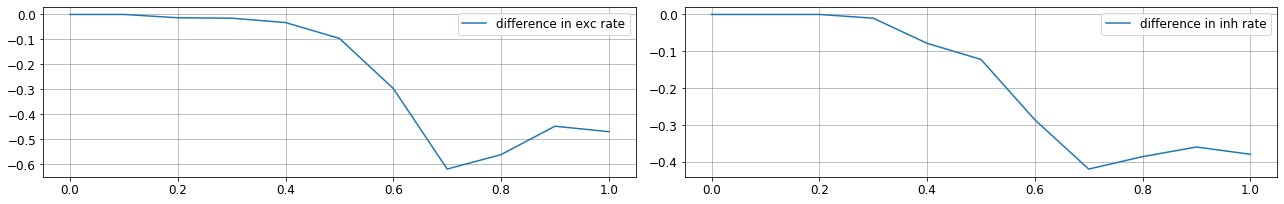

In [581]:
diff = rates1 - rates2
plot_dif(diff)
plt.savefig("diff.pdf")
print(diff[0,:])

In [666]:
max_cntrl = 50. * 5.
start_step = 100.
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
#control2 = control1
#control2[0,1,:] += 0.1
#control2[0,1,7] += 0.1

max_it = 1000
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(A1_bestControl, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [0])

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

set cost params
True 0
RUN  0 , total integrated cost =  4.249342194364126e-07
RUN  1 , total integrated cost =  4.243772846989772e-07
RUN  2 , total integrated cost =  4.240118866304506e-07
RUN  3 , total integrated cost =  4.2367189207018167e-07
RUN  4 , total integrated cost =  4.2307465317745285e-07
RUN  5 , total integrated cost =  4.2247939176672054e-07
RUN  6 , total integrated cost =  4.221309191763976e-07
RUN  7 , total integrated cost =  4.2177492175509356e-07
RUN  8 , total integrated cost =  4.2119706624920687e-07
RUN  9 , total integrated cost =  4.206651686387038e-07
RUN  10 , total integrated cost =  4.202732163990572e-07
RUN  11 , total integrated cost =  4.1988067537403984e-07
RUN  12 , total integrated cost =  4.1934961080959745e-07
RUN  13 , total integrated cost =  4.188535491019115e-07
RUN  14 , total integrated cost =  4.184290716468877e-07
RUN  15 , total integrated cost =  4.1798920184816497e-07
RUN  16 , total integrated cost =  4.175080604366207e-07
RUN  17 , 

RUN  32 , total integrated cost =  4.1004770104374377e-07
RUN  33 , total integrated cost =  4.096032406977541e-07
RUN  34 , total integrated cost =  4.091219389044919e-07
RUN  35 , total integrated cost =  4.086711651424341e-07
RUN  36 , total integrated cost =  4.081978055327103e-07
RUN  37 , total integrated cost =  4.0774128179225227e-07
RUN  38 , total integrated cost =  4.072752631833016e-07
RUN  39 , total integrated cost =  4.068135803158366e-07
RUN  40 , total integrated cost =  4.063542772318279e-07
RUN  41 , total integrated cost =  4.0588805093783113e-07
RUN  42 , total integrated cost =  4.0543481630666177e-07
RUN  43 , total integrated cost =  4.0496468438770534e-07
RUN  44 , total integrated cost =  4.045168523924968e-07
RUN  45 , total integrated cost =  4.0404347183802846e-07
RUN  46 , total integrated cost =  4.0360036095335927e-07
RUN  47 , total integrated cost =  4.031244048622911e-07
RUN  48 , total integrated cost =  4.0268532100597855e-07
RUN  49 , total integra

RUN  63 , total integrated cost =  3.9579906330223276e-07
too small start step, increase to  10000.0
RUN  64 , total integrated cost =  3.9517963635084854e-07
RUN  65 , total integrated cost =  3.945423173719471e-07
RUN  66 , total integrated cost =  3.9421911066032433e-07
RUN  67 , total integrated cost =  3.938757149702931e-07
RUN  68 , total integrated cost =  3.9328016187603577e-07
RUN  69 , total integrated cost =  3.9267313764093303e-07
RUN  70 , total integrated cost =  3.9233692554851524e-07
RUN  71 , total integrated cost =  3.92009781935477e-07
too small start step, increase to  10000.0
RUN  72 , total integrated cost =  3.913865692929732e-07
RUN  73 , total integrated cost =  3.9076521280666796e-07
RUN  74 , total integrated cost =  3.904382772967583e-07
RUN  75 , total integrated cost =  3.901050955581413e-07
too small start step, increase to  10000.0
RUN  76 , total integrated cost =  3.8949863135082077e-07
RUN  77 , total integrated cost =  3.8886666818232257e-07
RUN  78 

RUN  90 , total integrated cost =  3.8294037065346245e-07
RUN  91 , total integrated cost =  3.826262684957381e-07
too small start step, increase to  10000.0
RUN  92 , total integrated cost =  3.819981101902323e-07
RUN  93 , total integrated cost =  3.814117726484374e-07
RUN  94 , total integrated cost =  3.8107820514138533e-07
RUN  95 , total integrated cost =  3.8076766441322554e-07
too small start step, increase to  10000.0
RUN  96 , total integrated cost =  3.801366394103311e-07
RUN  97 , total integrated cost =  3.7955911226198777e-07
RUN  98 , total integrated cost =  3.792233823170558e-07
RUN  99 , total integrated cost =  3.7891817294117875e-07
too small start step, increase to  10000.0
RUN  100 , total integrated cost =  3.782789795527076e-07
RUN  101 , total integrated cost =  3.776002660862558e-07
RUN  102 , total integrated cost =  3.7731199395046346e-07
RUN  103 , total integrated cost =  3.770360575645753e-07
too small start step, increase to  10000.0
RUN  104 , total int

RUN  117 , total integrated cost =  3.701228810967669e-07
RUN  118 , total integrated cost =  3.697986576344653e-07
RUN  119 , total integrated cost =  3.694979917984053e-07
too small start step, increase to  10000.0
RUN  120 , total integrated cost =  3.6887125962374665e-07
RUN  121 , total integrated cost =  3.682130953915854e-07
RUN  122 , total integrated cost =  3.679264124673584e-07
RUN  123 , total integrated cost =  3.6762718247119576e-07
too small start step, increase to  10000.0
RUN  124 , total integrated cost =  3.6700167136872436e-07
RUN  125 , total integrated cost =  3.663488346715857e-07
RUN  126 , total integrated cost =  3.6606189000572786e-07
RUN  127 , total integrated cost =  3.6576591661172797e-07
too small start step, increase to  10000.0
RUN  128 , total integrated cost =  3.651372752772158e-07
RUN  129 , total integrated cost =  3.64494075107448e-07
RUN  130 , total integrated cost =  3.64205106511519e-07
RUN  131 , total integrated cost =  3.6391414379575847e-

...

RUN  881 , total integrated cost =  1.994180490855154e-07
RUN  882 , total integrated cost =  1.9934529842988694e-07
RUN  883 , total integrated cost =  1.9927246046706875e-07
RUN  884 , total integrated cost =  1.9920173629471366e-07
RUN  885 , total integrated cost =  1.9912698407707224e-07
RUN  886 , total integrated cost =  1.990580122731688e-07
RUN  887 , total integrated cost =  1.9899066806896656e-07
RUN  888 , total integrated cost =  1.9891404645595793e-07
RUN  889 , total integrated cost =  1.9883629415198252e-07
RUN  890 , total integrated cost =  1.9876998469062773e-07
RUN  891 , total integrated cost =  1.9870014271561082e-07
RUN  892 , total integrated cost =  1.9862668316086967e-07
RUN  893 , total integrated cost =  1.9855507580501834e-07
RUN  894 , total integrated cost =  1.9848356614139405e-07
RUN  895 , total integrated cost =  1.9841012044709223e-07
RUN  896 , total integrated cost =  1.9834051772546716e-07
RUN  897 , total integrated cost =  1.98274307521545e-07
R

RUN  909 , total integrated cost =  1.9741628311926477e-07
RUN  910 , total integrated cost =  1.973398336638931e-07
RUN  911 , total integrated cost =  1.9726312521023198e-07
RUN  912 , total integrated cost =  1.9719693514733915e-07
RUN  913 , total integrated cost =  1.9712805722062097e-07
RUN  914 , total integrated cost =  1.9705469501692728e-07
RUN  915 , total integrated cost =  1.9698413770853542e-07
RUN  916 , total integrated cost =  1.9691263218714878e-07
RUN  917 , total integrated cost =  1.9684032847945128e-07
RUN  918 , total integrated cost =  1.9677074915459391e-07
RUN  919 , total integrated cost =  1.9669662962405481e-07
RUN  920 , total integrated cost =  1.966286568036901e-07
RUN  921 , total integrated cost =  1.9656197669654767e-07
RUN  922 , total integrated cost =  1.96486398465325e-07
RUN  923 , total integrated cost =  1.9640948993183246e-07
RUN  924 , total integrated cost =  1.963439976825855e-07
RUN  925 , total integrated cost =  1.9627500122529732e-07
RU

RUN  935 , total integrated cost =  1.9556842324754315e-07
RUN  936 , total integrated cost =  1.9549451432121395e-07
RUN  937 , total integrated cost =  1.9541672643194135e-07
RUN  938 , total integrated cost =  1.953524749540683e-07
RUN  939 , total integrated cost =  1.9529161987158303e-07
RUN  940 , total integrated cost =  1.9523526131759615e-07
RUN  941 , total integrated cost =  1.9517500186823943e-07
RUN  942 , total integrated cost =  1.9511812764637018e-07
RUN  943 , total integrated cost =  1.950584550060634e-07
RUN  944 , total integrated cost =  1.9500107380498603e-07
RUN  945 , total integrated cost =  1.949419792250168e-07
RUN  946 , total integrated cost =  1.948840996579365e-07
RUN  947 , total integrated cost =  1.9482557447449398e-07
RUN  948 , total integrated cost =  1.9476720507163513e-07
RUN  949 , total integrated cost =  1.947092406992487e-07
RUN  950 , total integrated cost =  1.9465038990983204e-07
RUN  951 , total integrated cost =  1.9459297784532098e-07
RU

RUN  964 , total integrated cost =  1.9373771973038843e-07
RUN  965 , total integrated cost =  1.9366953319891866e-07
RUN  966 , total integrated cost =  1.9359788161747492e-07
RUN  967 , total integrated cost =  1.9352814210904096e-07
RUN  968 , total integrated cost =  1.934582082519356e-07
RUN  969 , total integrated cost =  1.933868587306186e-07
RUN  970 , total integrated cost =  1.9331867700326685e-07
RUN  971 , total integrated cost =  1.9325449223606843e-07
RUN  972 , total integrated cost =  1.931782920659982e-07
RUN  973 , total integrated cost =  1.9310454607601253e-07
RUN  974 , total integrated cost =  1.930385125290403e-07
RUN  975 , total integrated cost =  1.9297234461513835e-07
RUN  976 , total integrated cost =  1.9289891338602697e-07
RUN  977 , total integrated cost =  1.9282265560066253e-07
RUN  978 , total integrated cost =  1.9275886378109254e-07
RUN  979 , total integrated cost =  1.9269061751389598e-07
RUN  980 , total integrated cost =  1.9261971609476987e-07
R

RUN  993 , total integrated cost =  1.91725196620474e-07
RUN  994 , total integrated cost =  1.91669566559906e-07
RUN  995 , total integrated cost =  1.916107073701002e-07
RUN  996 , total integrated cost =  1.9155450813243118e-07
RUN  997 , total integrated cost =  1.9149628836398337e-07
RUN  998 , total integrated cost =  1.9143953125448458e-07
RUN  999 , total integrated cost =  1.9138193953832494e-07
RUN  1000 , total integrated cost =  1.9132463571206595e-07
Improved over  1000  iterations by  54.97546985841279  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([5], dtype=int64)) 5.641480294760201e-06
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([8], dtype=int64)) -3.175289402368699e-06
cost decreases throughout computation


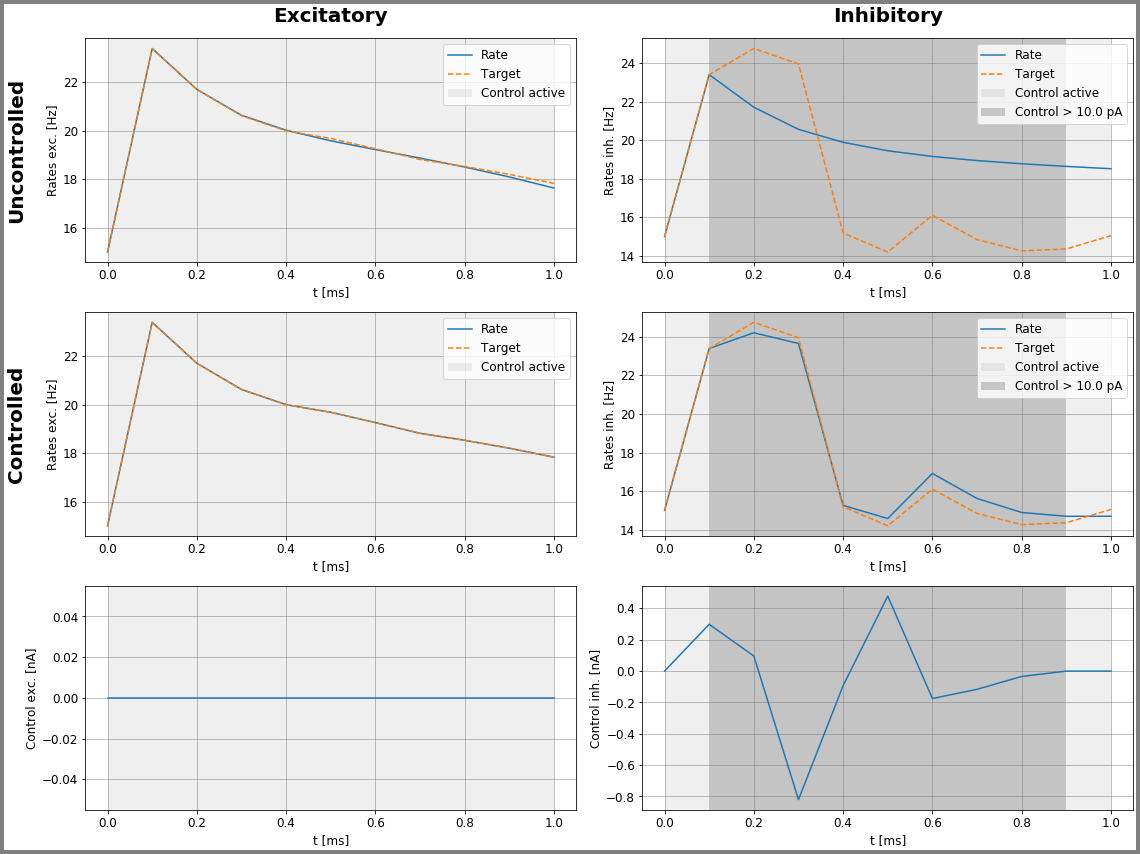

In [664]:
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1_inh.pdf')

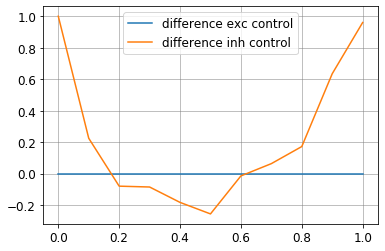

runtime =  20.232390599994687
control difference =  0.36723979917980415
best control =  [ 0.      1.6005  0.4418 -4.1424 -0.5548  2.2658 -0.8825 -0.5539 -0.0847
  0.      0.    ]


In [667]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

print("runtime = ", runtime[-1])
d_int = diff_control(cDiff)
print("control difference = ", d_int)
print("best control = ", A1_bestControl[0,1,:])

#plt.plot(aln.t, grad[0,1,:])
#plt.show()

### For excitatory control input only

max delay =  0


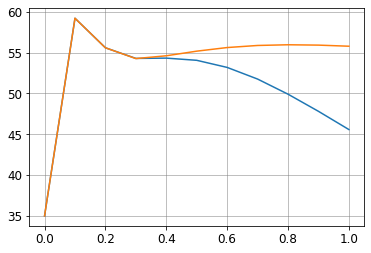

In [462]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

[35.         59.21274616 55.596433   54.29251745 54.32843987 54.0599205
 53.18944733 51.76301918 49.91022479 44.80662342 42.97043573]
[35.         59.21274616 55.59188139 54.27301682 54.61441869 55.18057563
 55.62309066 55.87812338 55.96401521 55.92051272 55.78592652]


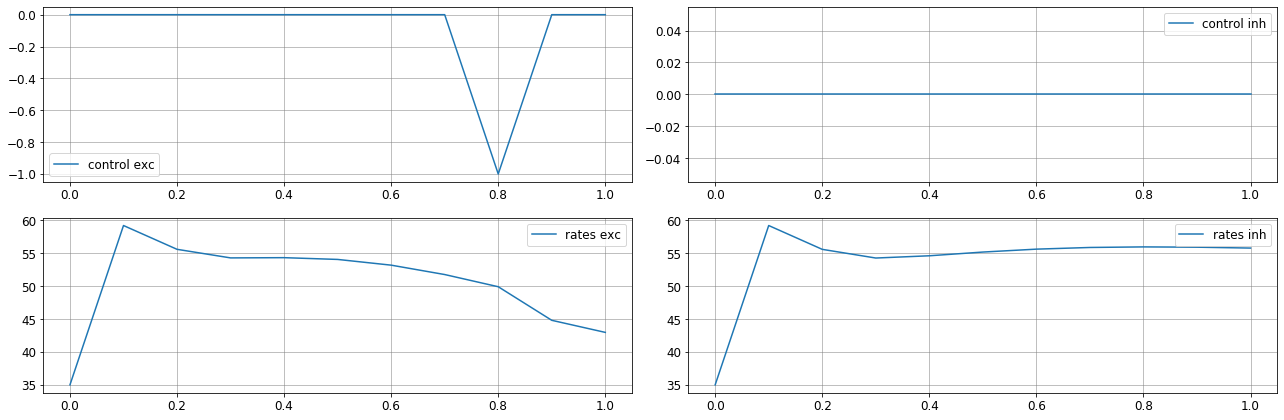

In [492]:
dur = 1.
aln.params.duration = dur
aln.params.de = 0.0
aln.params.di = 0.0

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)

control1 = aln.getZeroControl()
#control1[0,0,1] -= 1.
#control1[0,0,3] += 1.
#control1[0,0,5] -= 1.
#control1[0,0,7] += 1.
control1[0,0,8] -= 1.
#control1[0,0,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

#aln.params.de = 0.2

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0, control1)
plt.savefig("exc_control_no_delay.pdf")
rates1 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[35.         59.21274616 55.596433   54.29251745 54.32843987 54.0599205
 53.18944733 51.76301918 49.91022479 47.81037938 45.57777361]
[35.         59.21274616 55.59188139 54.27301682 54.61441869 55.18057563
 55.62309066 55.87812338 55.96401521 55.92051272 55.7859217 ]


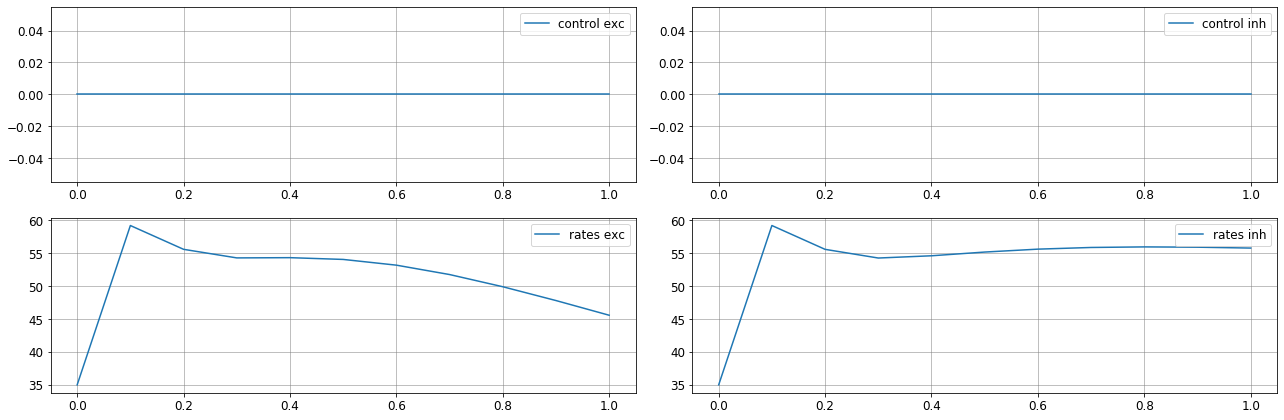

In [494]:
#aln.params.de = 0.2
set_init(initvars)
cntrl = aln.getZeroControl()
aln.run(control=cntrl)

rates2 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])
plot_fig(0, cntrl)
plt.savefig("exc_control_delay.pdf")

#target[:,0,:] = aln.state["rates_exc"][0,:]
#target[:,1,:] = aln.state["rates_inh"][0,:]

(2, 11)
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.         -3.00375595 -2.60733788]


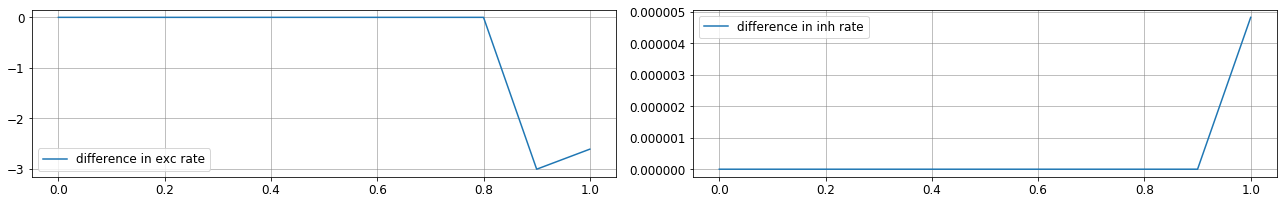

In [495]:
diff = rates1 - rates2
print(diff.shape)
plot_dif(diff)
plt.savefig("diff_exc.pdf")
print(diff[0,:])

In [508]:
max_cntrl = 50. * 5.
start_step = 1e3
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()

max_it = 100
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [1])

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

set cost params
True 0
RUN  0 , total integrated cost =  1.162913337862592e-12
RUN  1 , total integrated cost =  7.767613042126656e-13
RUN  2 , total integrated cost =  6.642869538773147e-13
RUN  3 , total integrated cost =  5.859276498132149e-13
RUN  4 , total integrated cost =  4.782335557037573e-13
RUN  5 , total integrated cost =  4.217156311017318e-13
RUN  6 , total integrated cost =  4.0387099710174406e-13
RUN  7 , total integrated cost =  3.9006882883030885e-13
RUN  8 , total integrated cost =  3.826622964692288e-13
RUN  9 , total integrated cost =  3.7546656645857647e-13
RUN  10 , total integrated cost =  3.664209730542012e-13
RUN  11 , total integrated cost =  3.5884009246962606e-13
RUN  12 , total integrated cost =  3.531238622170053e-13
RUN  13 , total integrated cost =  3.480962034528841e-13
RUN  14 , total integrated cost =  3.4134383438335135e-13
RUN  15 , total integrated cost =  3.3511196742427535e-13
RUN  16 , total integrated cost =  3.307767239485994e-13
RUN  17 , to

[ 0.00000000e+00 -3.65868289e-07 -4.84333007e-06  3.91516008e-06
  1.90955975e-05  3.06825256e-05  2.51785972e-05  6.23540267e-10
 -4.60913593e-09  0.00000000e+00  0.00000000e+00]


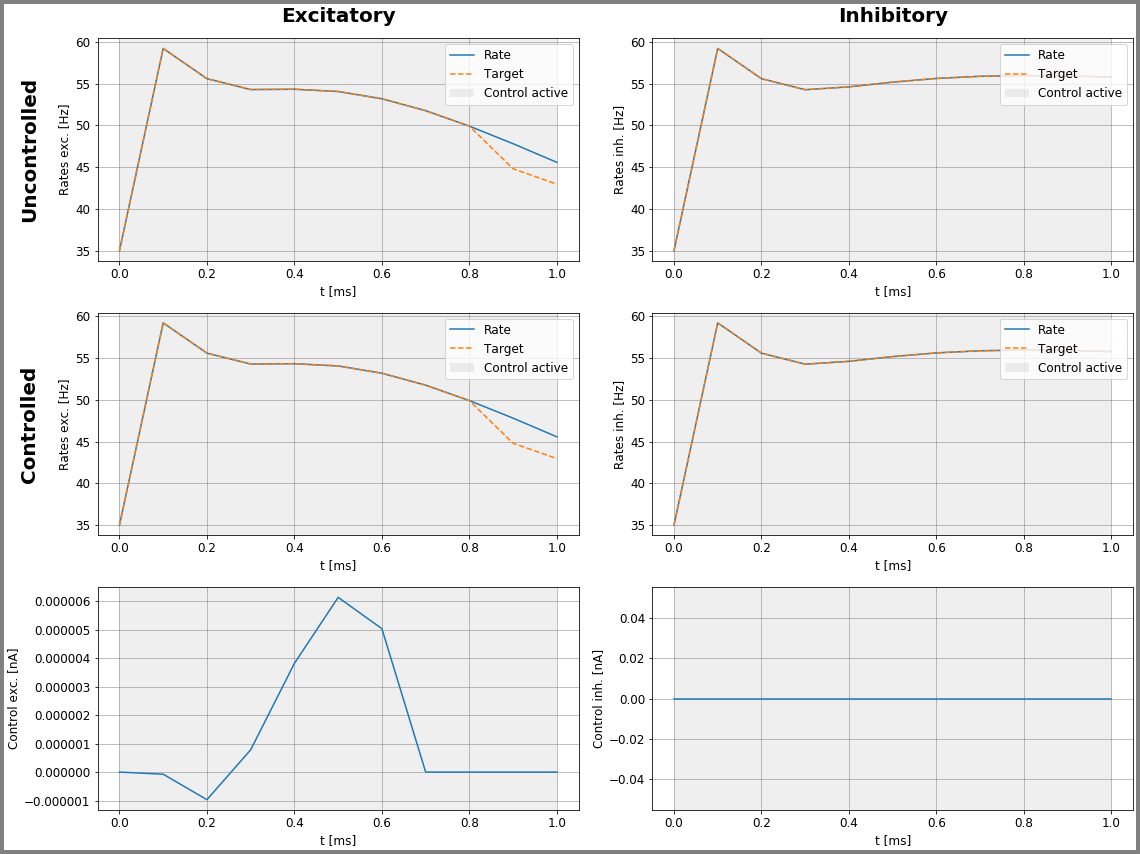

In [507]:
print(A1_bestControl[0,0,:])
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1_exc.pdf')

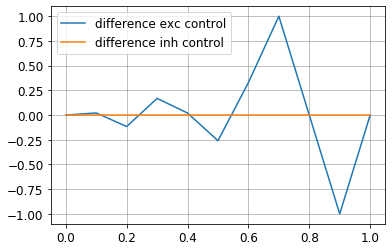

runtime =  22.674976700000116
Control difference =  0.2915434140474991


In [487]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

print("runtime = ", runtime[-1])
d_int = diff_control(cDiff)
print("Control difference = ", d_int)

[ 0.00000000e+00 -1.10740980e-07  3.90450853e-07 -5.70758250e-04
  8.99706861e-04  4.02199115e-07 -3.71519673e-07 -1.55168468e-07
 -1.72553209e-07  0.00000000e+00  0.00000000e+00]


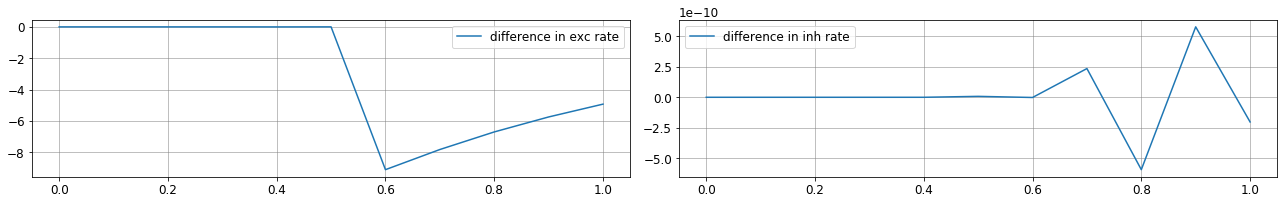

In [408]:
set_init(initvars)
aln.run(control=A1_bestControl)
rates3 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )

diff1 = rates3 - rates2
plot_dif(diff1)
plt.savefig("diff1_exc.pdf")
print(A1_bestControl[0,0,:])


[ 0.00000000e+00 -1.10740980e-07  3.90450853e-07 -5.70763250e-04
  8.99716861e-04  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00]


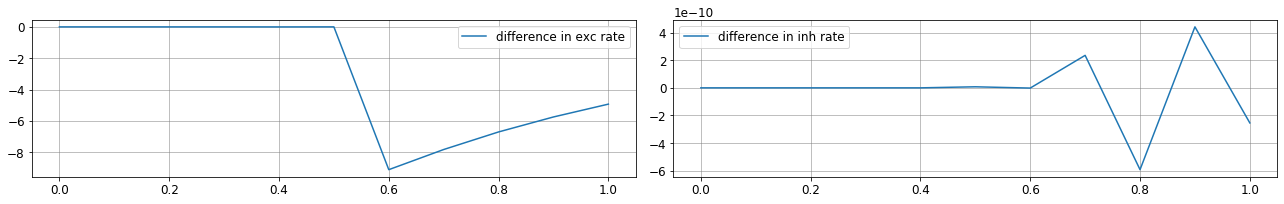

In [423]:
test_control = A1_bestControl.copy()
test_control[0,0,5:] = 0.
test_control[0,0,4] += 1e-8
test_control[0,0,3] -= 5.*1e-9

set_init(initvars)
aln.run(control=test_control)
rates3 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )

diff1 = rates3 - rates2
plot_dif(diff1)
plt.savefig("diff1_exc.pdf")
print(test_control[0,0,:])